In [9]:

from pathlib import Path
import json
from datetime import datetime, timezone

import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)

from temgym_core.constants import energy2wavelength
from temgym_core.components import Lens, Plane, Detector
from temgym_core.gaussian import make_gaussian
from temgym_core.source import make_waist_divergence_rays
from temgym_core.run import run_to_end
from temgym_core.evaluate import evaluate_gaussians_for
from temgym_core.plotting import plot_model, legacy_beam_plot_params
from temgym_core.ray import Ray

import jax.numpy as jnp


In [10]:
def P_np(d):
    return np.array([[1.0, float(d)], [0.0, 1.0]], dtype=float)


def L_np(f):
    return np.array([[1.0, 0.0], [-1.0 / float(f), 1.0]], dtype=float)


def compose_forward_np(ops):
    M = np.eye(2, dtype=float)
    for op in ops:
        M = np.asarray(op, dtype=float) @ M
    return M


def P_jax(d):
    return jnp.array([[1.0, d], [0.0, 1.0]], dtype=jnp.float64)


def L_jax(f):
    return jnp.array([[1.0, 0.0], [-1.0 / f, 1.0]], dtype=jnp.float64)


def compose_forward_jax(ops):
    M = jnp.eye(2, dtype=jnp.float64)
    for op in ops:
        M = op @ M
    return M


def matrix_S_to_A_np(f_cl1, f_cl3, cfg_local):
    return compose_forward_np([
        P_np(cfg_local['d_S_C1']),
        L_np(f_cl1),
        P_np(cfg_local['d_C1_C3']),
        L_np(f_cl3),
        P_np(cfg_local['d_C3_A']),
    ])


def matrix_S_to_FOPL_np(f_cl1, f_cl3, f_cmini, cfg_local):
    return compose_forward_np([
        P_np(cfg_local['d_S_C1']),
        L_np(f_cl1),
        P_np(cfg_local['d_C1_C3']),
        L_np(f_cl3),
        P_np(cfg_local['d_C3_A']),
        P_np(cfg_local['d_A_Cmini']),
        L_np(f_cmini),
        P_np(cfg_local['d_Cmini_OPL'] - cfg_local['f_OPL']),
    ])


def matrix_S_to_Sp_np(f_cl1, f_cl3, f_cmini, cfg_local):
    return compose_forward_np([
        P_np(cfg_local['d_S_C1']),
        L_np(f_cl1),
        P_np(cfg_local['d_C1_C3']),
        L_np(f_cl3),
        P_np(cfg_local['d_C3_A']),
        P_np(cfg_local['d_A_Cmini']),
        L_np(f_cmini),
        P_np(cfg_local['d_Cmini_OPL']),
        L_np(cfg_local['f_OPL']),
        P_np(cfg_local['d_OPL_Sp']),
    ])


def matrix_S_to_FOPL_jax(f_cl1, f_cl3, f_cmini, cfg_local):
    return compose_forward_jax([
        P_jax(cfg_local['d_S_C1']),
        L_jax(f_cl1),
        P_jax(cfg_local['d_C1_C3']),
        L_jax(f_cl3),
        P_jax(cfg_local['d_C3_A']),
        P_jax(cfg_local['d_A_Cmini']),
        L_jax(f_cmini),
        P_jax(cfg_local['d_Cmini_OPL'] - cfg_local['f_OPL']),
    ])


def matrix_S_to_Sp_jax(f_cl1, f_cl3, f_cmini, cfg_local):
    return compose_forward_jax([
        P_jax(cfg_local['d_S_C1']),
        L_jax(f_cl1),
        P_jax(cfg_local['d_C1_C3']),
        L_jax(f_cl3),
        P_jax(cfg_local['d_C3_A']),
        P_jax(cfg_local['d_A_Cmini']),
        L_jax(f_cmini),
        P_jax(cfg_local['d_Cmini_OPL']),
        L_jax(cfg_local['f_OPL']),
        P_jax(cfg_local['d_OPL_Sp']),
    ])
    
def metrics_from_matrices_np(f_cl1, f_cl3, f_cmini, cfg_local):
    M_fopl = matrix_S_to_FOPL_np(f_cl1, f_cl3, f_cmini, cfg_local)
    B_s_to_fopl = float(M_fopl[0, 1])

    M_sp = matrix_S_to_Sp_np(f_cl1, f_cl3, f_cmini, cfg_local)
    A, B, C, D = float(M_sp[0, 0]), float(M_sp[0, 1]), float(M_sp[1, 0]), float(M_sp[1, 1])

    lam = cfg_local['wavelength']
    qinv_in = 1j * lam / (np.pi * cfg_local['waist_in'] ** 2)
    denom = A + B * qinv_in
    qinv_out = (C + D * qinv_in) / denom

    im_qinv = float(np.imag(qinv_out))
    if im_qinv <= 0.0:
        fwhm = np.nan
    else:
        w = np.sqrt(lam / (np.pi * im_qinv))
        fwhm = np.sqrt(2.0 * np.log(2.0)) * w

    alpha = abs(D) * cfg_local['theta0']
    return {
        'B_SFOPL': B_s_to_fopl,
        'fwhm': float(fwhm),
        'alpha': float(alpha),
        'A_SSp': A,
        'D_SSp': D,
        'qinv_out': complex(qinv_out),
    }

## Export And Reuse The Fitted Microscope Model

This section exports the fitted CL3-only microscope model to JSON, loads it back,
and provides a routine to choose a sample FWHM and realize focal lengths in TemGym.


In [11]:
def build_export_payload_from_cl3_only_fit(cfg_local, cfg_cl3, cl3_results):
    rows = [r for r in cl3_results if r['success']]
    if not rows:
        raise ValueError('Cannot export model: CL3-only fit has no successful rows.')

    rows = sorted(rows, key=lambda r: r['target_fwhm'])
    fit_table = []
    for r in rows:
        fit_table.append({
            'target_fwhm_nm': float(r['target_fwhm'] * 1e9),
            'achieved_fwhm_nm': float(r['fwhm'] * 1e9),
            'f_CL3_m': float(r['f_CL3']),
            'alpha_mrad': float(r['alpha'] * 1e3),
            'B_SFOPL': float(r['B_SFOPL']),
            'stage': str(r.get('stage', '')),
            'status': str(r.get('status', '')),
        })

    payload = {
        'model_type': 'tem_condenser_cl3_only_fit',
        'schema_version': 1,
        'exported_at_utc': datetime.now(timezone.utc).isoformat(),
        'branch_mode': str(cfg_cl3['branch_mode']),
        'beam': {
            'voltage_V': float(cfg_local['voltage']),
            'waist_m': float(cfg_local['waist_in']),
            'alpha_cap_mrad': float(cfg_cl3['alpha_cap_mrad']),
        },
        'fixed_focals_m': {
            'f_CL1_m': float(cfg_cl3['f_CL1_fixed_m']),
            'f_Cmini_m': float(cfg_cl3['f_Cmini_fixed_m']),
            'f_OPL_m': float(cfg_local['f_OPL']),
        },
        'geometry_m': {
            'd_S_C1': float(cfg_local['d_S_C1']),
            'd_C1_C3': float(cfg_local['d_C1_C3']),
            'd_C3_A': float(cfg_local['d_C3_A']),
            'd_A_Cmini': float(cfg_local['d_A_Cmini']),
            'd_Cmini_OPL': float(cfg_local['d_Cmini_OPL']),
            'd_OPL_Sp': float(cfg_local['d_OPL_Sp']),
        },
        'fit_table': fit_table,
    }
    return payload


def export_fit_model_json(payload, path):
    out = Path(path)
    out.parent.mkdir(parents=True, exist_ok=True)
    out.write_text(json.dumps(payload, indent=2))
    return out


def load_fit_model_json(path):
    return json.loads(Path(path).read_text())


def make_eval_cfg_from_export(model):
    c = {
        'voltage': float(model['beam']['voltage_V']),
        'waist_in': float(model['beam']['waist_m']),
        'f_OPL': float(model['fixed_focals_m']['f_OPL_m']),
        'd_S_C1': float(model['geometry_m']['d_S_C1']),
        'd_C1_C3': float(model['geometry_m']['d_C1_C3']),
        'd_C3_A': float(model['geometry_m']['d_C3_A']),
        'd_A_Cmini': float(model['geometry_m']['d_A_Cmini']),
        'd_Cmini_OPL': float(model['geometry_m']['d_Cmini_OPL']),
        'd_OPL_Sp': float(model['geometry_m']['d_OPL_Sp']),
    }
    c['wavelength'] = float(np.asarray(energy2wavelength(c['voltage'])))
    c['theta0'] = c['wavelength'] / (np.pi * c['waist_in'])
    return c


def realize_focals_for_target_fwhm_nm(model, target_fwhm_nm, mode='interpolate'):
    table = sorted(model['fit_table'], key=lambda row: row['target_fwhm_nm'])
    t = np.array([row['target_fwhm_nm'] for row in table], dtype=float)
    f3 = np.array([row['f_CL3_m'] for row in table], dtype=float)
    ach = np.array([row['achieved_fwhm_nm'] for row in table], dtype=float)
    alpha = np.array([row['alpha_mrad'] for row in table], dtype=float)

    target = float(target_fwhm_nm)
    t_clip = float(np.clip(target, float(t.min()), float(t.max())))

    if mode == 'nearest':
        i = int(np.argmin(np.abs(t - target)))
        f_cl3 = float(f3[i])
        achieved_nm = float(ach[i])
        alpha_mrad = float(alpha[i])
    elif mode == 'interpolate':
        f_cl3 = float(np.interp(t_clip, t, f3))
        achieved_nm = float(np.interp(t_clip, t, ach))
        alpha_mrad = float(np.interp(t_clip, t, alpha))
    else:
        raise ValueError("mode must be 'interpolate' or 'nearest'")

    return {
        'target_fwhm_nm': target,
        'target_fwhm_nm_clipped': t_clip,
        'mode': mode,
        'f_CL1_m': float(model['fixed_focals_m']['f_CL1_m']),
        'f_CL3_m': f_cl3,
        'f_Cmini_m': float(model['fixed_focals_m']['f_Cmini_m']),
        'f_OPL_m': float(model['fixed_focals_m']['f_OPL_m']),
        'fit_pred_achieved_fwhm_nm': achieved_nm,
        'fit_pred_alpha_mrad': alpha_mrad,
    }


def build_temgym_components_from_realization(model, realized):
    g = model['geometry_m']
    z0 = 0.0
    z_c1 = z0 + float(g['d_S_C1'])
    z_c3 = z_c1 + float(g['d_C1_C3'])
    z_cmini = z_c3 + float(g['d_C3_A']) + float(g['d_A_Cmini'])
    z_opl = z_cmini + float(g['d_Cmini_OPL'])
    z_sp = z_opl + float(g['d_OPL_Sp'])

    comps = (
        Lens(z=z_c1, focal_length=float(realized['f_CL1_m'])),
        Lens(z=z_c3, focal_length=float(realized['f_CL3_m'])),
        Lens(z=z_cmini, focal_length=float(realized['f_Cmini_m'])),
        Lens(z=z_opl, focal_length=float(realized['f_OPL_m'])),
        Plane(z=z_sp),
    )
    return comps


def make_center_ray(z=0.0):
    return Ray(
        x=np.asarray([0.0], dtype=float),
        y=np.asarray([0.0], dtype=float),
        dx=np.asarray([0.0], dtype=float),
        dy=np.asarray([0.0], dtype=float),
        z=np.asarray([z], dtype=float),
        pathlength=np.asarray([0.0], dtype=float),
    )



In [12]:
loaded_model = load_fit_model_json('examples/ray_transfer/exported_microscope_models/condenser_cl3_only_fit_model.json')
print('Loaded model type:', loaded_model['model_type'])
print('Loaded branch mode:', loaded_model['branch_mode'])


Loaded model type: tem_condenser_cl3_only_fit
Loaded branch mode: low


## Choose Sample FWHM -> Realize Focal Lengths -> Plot TemGym Ray Paths

Use `requested_fwhm_nm` to select a microscope setting from the exported model.
`make_waist_divergence_rays(...)` provides the two fundamental rays for path plotting.


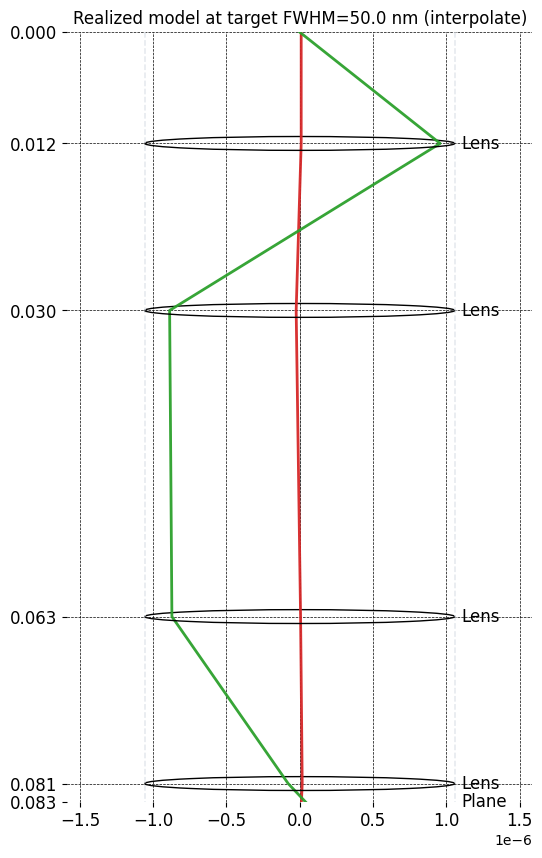

Realized focal lengths [mm]:
  f_CL1  : 5.253
  f_CL3  : 8.617608333333333
  f_Cmini: 20.0
  f_OPL  : 5.0
Requested FWHM [nm]: 50.0
Target after clipping [nm]: 50.00000000000001
Fit-predicted achieved FWHM [nm]: 50.01844290647434
Matrix achieved FWHM [nm]: 50.01844290647434
Matrix alpha [mrad]: 0.059824264986175324
Matrix B(S->F_OPL): -0.003746977970890222


In [16]:
# User controls
requested_fwhm_nm = 50.0
realize_mode = 'interpolate'  # 'interpolate' or 'nearest'

realized = realize_focals_for_target_fwhm_nm(
    loaded_model,
    target_fwhm_nm=requested_fwhm_nm,
    mode=realize_mode,
)

components_realized = build_temgym_components_from_realization(loaded_model, realized)

# Two fundamental rays from source utilities (waist + divergence basis)
fundamental_rays = make_waist_divergence_rays(
    loaded_model['beam']['waist_m'],
    voltage=loaded_model['beam']['voltage_V'],
    z=0.0,
)

# A central ray is used as the primary bundle for plot_model
center_ray = make_center_ray(z=0.0)

fig, ax = plot_model(
    components_realized,
    rays=center_ray,
    solution_rays=fundamental_rays,
    include_input_rays=True,
)
ax.set_title(f"Realized model at target FWHM={requested_fwhm_nm:.1f} nm ({realize_mode})")
plt.show()

eval_cfg_loaded = make_eval_cfg_from_export(loaded_model)
m_realized = metrics_from_matrices_np(
    f_cl1=realized['f_CL1_m'],
    f_cl3=realized['f_CL3_m'],
    f_cmini=realized['f_Cmini_m'],
    cfg_local=eval_cfg_loaded,
)

print('Realized focal lengths [mm]:')
print('  f_CL1  :', realized['f_CL1_m'] * 1e3)
print('  f_CL3  :', realized['f_CL3_m'] * 1e3)
print('  f_Cmini:', realized['f_Cmini_m'] * 1e3)
print('  f_OPL  :', realized['f_OPL_m'] * 1e3)
print('Requested FWHM [nm]:', realized['target_fwhm_nm'])
print('Target after clipping [nm]:', realized['target_fwhm_nm_clipped'])
print('Fit-predicted achieved FWHM [nm]:', realized['fit_pred_achieved_fwhm_nm'])
print('Matrix achieved FWHM [nm]:', m_realized['fwhm'] * 1e9)
print('Matrix alpha [mrad]:', m_realized['alpha'] * 1e3)
print('Matrix B(S->F_OPL):', m_realized['B_SFOPL'])


## Gaussian Beam Image At Sample Plane

This section uses:

- `make_gaussian(...)` for the input beam
- `run_to_end(...)` to propagate through the realized microscope model
- `evaluate_gaussians_for(...)` to render a 2D complex field on a sample-plane detector

and plots the resulting intensity image on the sample plane.


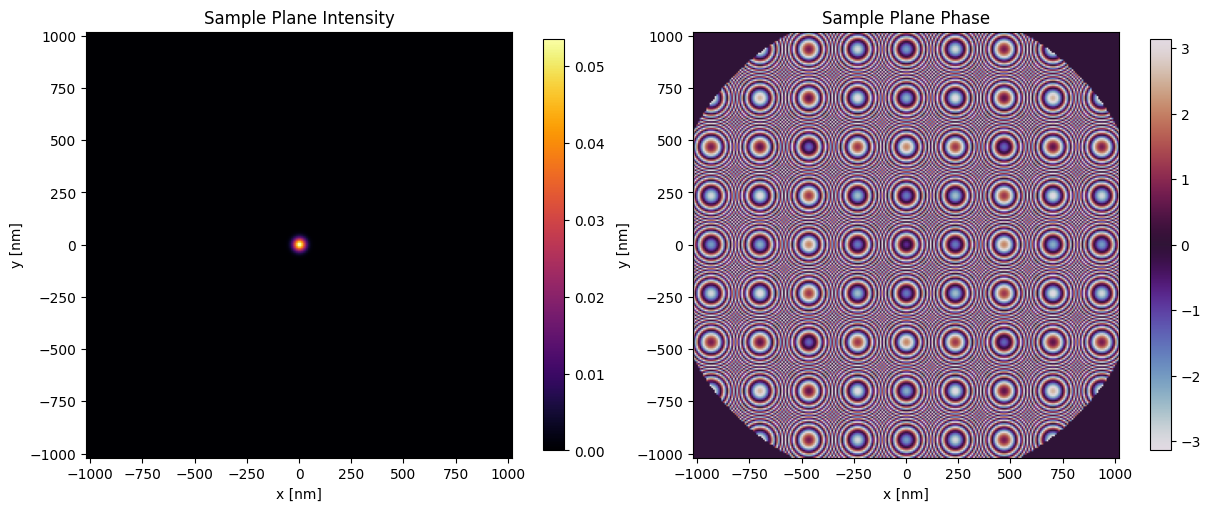

Requested target FWHM [nm]: 50.0
Predicted FWHM from matrix [nm]: 50.01844290647434
Image-estimated FWHM (center row) [nm]: 39.99999999999983
Predicted alpha [mrad]: 0.059824264986175324


In [17]:
# Imaging grid controls (sample plane)
sample_pixel_size_nm = 8.0
sample_shape = (256, 256)  # (y, x)

# Use the realized model from the previous section
realized_for_image = realized
model_for_image = loaded_model

# Reconstruct z positions from exported geometry
g = model_for_image['geometry_m']
z0 = 0.0
z_c1 = z0 + float(g['d_S_C1'])
z_c3 = z_c1 + float(g['d_C1_C3'])
z_cmini = z_c3 + float(g['d_C3_A']) + float(g['d_A_Cmini'])
z_opl = z_cmini + float(g['d_Cmini_OPL'])
z_sp = z_opl + float(g['d_OPL_Sp'])

sample_detector = Detector(
    z=z_sp,
    pixel_size=(sample_pixel_size_nm * 1e-9, sample_pixel_size_nm * 1e-9),
    shape=sample_shape,
)

components_for_image = (
    Lens(z=z_c1, focal_length=float(realized_for_image['f_CL1_m'])),
    Lens(z=z_c3, focal_length=float(realized_for_image['f_CL3_m'])),
    Lens(z=z_cmini, focal_length=float(realized_for_image['f_Cmini_m'])),
    Lens(z=z_opl, focal_length=float(realized_for_image['f_OPL_m'])),
    sample_detector,
)

# Single fundamental Gaussian beam input at source
beam_in = make_gaussian(
    x=0.0,
    y=0.0,
    dx=0.0,
    dy=0.0,
    z=0.0,
    voltage=float(model_for_image['beam']['voltage_V']),
    waist_x=float(model_for_image['beam']['waist_m']),
    waist_y=float(model_for_image['beam']['waist_m']),
)

beam_at_sample = run_to_end(beam_in, components_for_image)
field_sample = evaluate_gaussians_for(beam_at_sample, sample_detector)
field_sample = np.asarray(field_sample)
intensity_sample = np.abs(field_sample) ** 2
phase_sample = np.angle(field_sample)

# Detector coordinates for plotting
det_x, det_y = sample_detector.coords_1d
x_nm = np.asarray(det_x, dtype=float) * 1e9
y_nm = np.asarray(det_y, dtype=float) * 1e9
extent = (float(np.min(x_nm)), float(np.max(x_nm)), float(np.min(y_nm)), float(np.max(y_nm)))

# Optional image-estimated FWHM from center row (intensity half max)
row = intensity_sample[intensity_sample.shape[0] // 2, :]
half_max = 0.5 * float(np.max(row))
idx = np.where(row >= half_max)[0]
if idx.size >= 2:
    fwhm_img_nm = float(x_nm[idx[-1]] - x_nm[idx[0]])
else:
    fwhm_img_nm = np.nan

eval_cfg_loaded = make_eval_cfg_from_export(model_for_image)
m_realized = metrics_from_matrices_np(
    f_cl1=float(realized_for_image['f_CL1_m']),
    f_cl3=float(realized_for_image['f_CL3_m']),
    f_cmini=float(realized_for_image['f_Cmini_m']),
    cfg_local=eval_cfg_loaded,
)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im0 = axs[0].imshow(
    intensity_sample,
    extent=extent,
    origin='lower',
    cmap='inferno',
)
axs[0].set_title('Sample Plane Intensity')
axs[0].set_xlabel('x [nm]')
axs[0].set_ylabel('y [nm]')
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(
    phase_sample,
    extent=extent,
    origin='lower',
    cmap='twilight',
)
axs[1].set_title('Sample Plane Phase')
axs[1].set_xlabel('x [nm]')
axs[1].set_ylabel('y [nm]')
plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.show()

print('Requested target FWHM [nm]:', realized_for_image['target_fwhm_nm'])
print('Predicted FWHM from matrix [nm]:', m_realized['fwhm'] * 1e9)
print('Image-estimated FWHM (center row) [nm]:', fwhm_img_nm)
print('Predicted alpha [mrad]:', m_realized['alpha'] * 1e3)


## Input Divergence Fan Ray Plot

Use the source divergence basis (`make_waist_divergence_rays`) to define `theta0`, then launch a many-ray fan at the source and plot trajectories through the realized condenser stack.


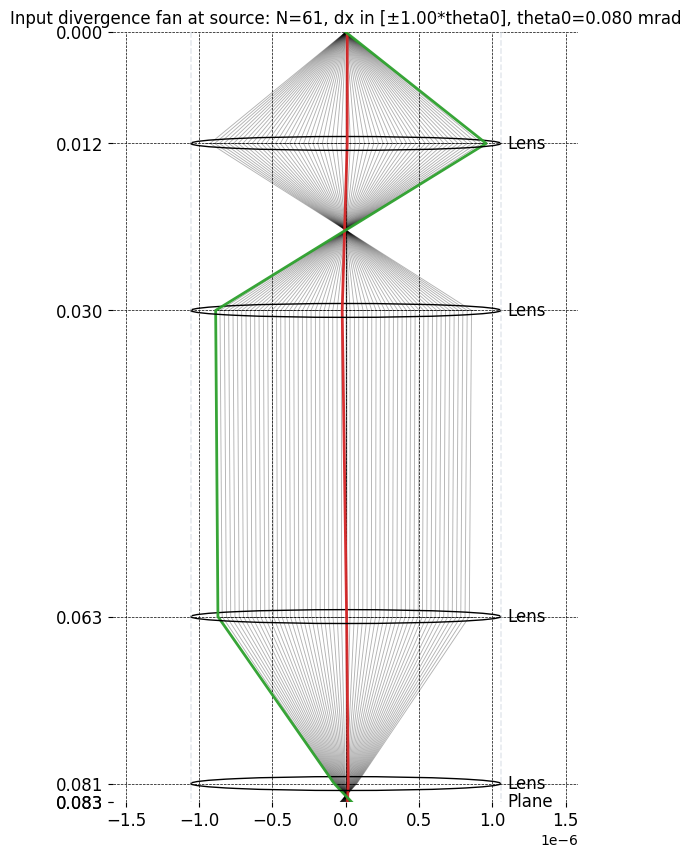

theta0 [mrad]: 0.07983001961973378
fan dx range [mrad]: -0.07983001961973378 to 0.07983001961973378


In [18]:
# Fan controls
fan_num_rays = 61                 # odd count keeps an on-axis ray
fan_divergence_scale = 1.0        # 1.0 -> +/- theta0
fan_band_mode = 'lines'           # 'lines' or 'fill'

# Build the two-ray basis to extract input divergence theta0
source_basis = make_waist_divergence_rays(
    loaded_model['beam']['waist_m'],
    voltage=loaded_model['beam']['voltage_V'],
    z=0.0,
)
source_basis_dx = np.asarray(source_basis.dx, dtype=float).reshape(-1)
theta0_in = float(np.max(np.abs(source_basis_dx)))

# Construct an x-z fan from -theta_max to +theta_max at source
theta_max = fan_divergence_scale * theta0_in
dx_fan = np.linspace(-theta_max, theta_max, int(fan_num_rays), dtype=float)

fan_rays = Ray(
    x=np.zeros_like(dx_fan),
    y=np.zeros_like(dx_fan),
    dx=dx_fan,
    dy=np.zeros_like(dx_fan),
    z=np.zeros_like(dx_fan),
    pathlength=np.zeros_like(dx_fan),
)

fig, ax = plot_model(
    components_realized,
    rays=fan_rays,
    solution_rays=source_basis,
    include_input_rays=True,
    plot_params=legacy_beam_plot_params(),
    band_mode=fan_band_mode,
)
ax.set_title(
    f"Input divergence fan at source: N={fan_num_rays}, "
    f"dx in [\u00b1{fan_divergence_scale:.2f}*theta0], theta0={theta0_in*1e3:.3f} mrad"
)
plt.show()

print('theta0 [mrad]:', theta0_in * 1e3)
print('fan dx range [mrad]:', float(dx_fan.min() * 1e3), 'to', float(dx_fan.max() * 1e3))
